<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=200>

*Milton Orlando Sarria Paja, PhD.*

---

# Máquinas de Vectores de Soporte (SVM)



---
## 1. ¿Por qué un margen máximo?


Imagina que tienes dos grupos de puntos en un plano (por ejemplo, correos **spam** vs. **no spam**, representados por sus características). Quieres trazar una línea que los separe.

El problema es que **existen infinitas líneas** que logran separar correctamente los dos grupos. La pregunta que responde SVM es: **¿cuál de todas esas líneas es la mejor?**

La respuesta de SVM: la línea que dejas **la mayor "calle" posible** entre los dos grupos, es decir, la que maximiza la distancia mínima entre la línea y el punto más cercano de cada clase. A esa distancia (al ancho de la calle) lo llamamos **margen**.

Veámoslo con un ejemplo antes de escribir una sola fórmula: generamos un conjunto de puntos separables y dibujamos **varias líneas candidatas** que separan perfectamente las dos clases. Todas son "correctas" en el sentido de que clasifican bien los datos de entrenamiento, pero intuitivamente algunas se ven más "riesgosas" (pasan muy cerca de algunos puntos) que otras.


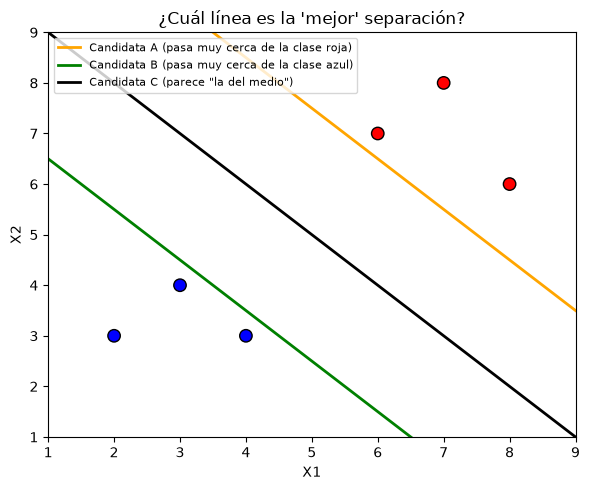

Las tres líneas clasifican bien los 6 puntos de entrenamiento.
¿Pero cuál preferirías si llegara un punto nuevo, ligeramente distinto, para clasificar?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# Datos de ejemplo: dos clases separables (mismos datos que usaremos en toda la sección 1)
X = np.array([[2, 3], [3, 4], [4, 3], [6, 7], [7, 8], [8, 6]])
y = np.array([0, 0, 0, 1, 1, 1])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=80, edgecolors='k', zorder=3)

# Varias líneas candidatas que separan correctamente los datos (elegidas a mano).
# Los clusters están alineados en diagonal (dirección (1,1)), así que la recta
# separadora debe tener pendiente NEGATIVA (perpendicular a esa diagonal), no +1.
# Con y = -x + b, se necesita 7 < b < 13 (el hueco entre las dos clases en x+y).
x_plot = np.linspace(1, 9, 50)
candidatas = [
    (-1.0, 12.5, 'orange', 'Candidata A (pasa muy cerca de la clase roja)'),
    (-1.0, 7.5,  'green',  'Candidata B (pasa muy cerca de la clase azul)'),
    (-1.0, 10.0, 'black',  'Candidata C (parece "la del medio")'),
]
for pendiente, intercepto, color, label in candidatas:
    ax.plot(x_plot, pendiente * x_plot + intercepto, color=color, lw=2, label=label)

ax.set_title("¿Cuál línea es la 'mejor' separación?")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_xlim(1, 9)
ax.set_ylim(1, 9)
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print("Las tres líneas clasifican bien los 6 puntos de entrenamiento.")
print("¿Pero cuál preferirías si llegara un punto nuevo, ligeramente distinto, para clasificar?")

Las tres líneas separan perfectamente los datos de entrenamiento, pero **no son igual de confiables**. Las candidatas A y B pasan muy cerca de algunos puntos: un dato nuevo, apenas un poco distinto a los de entrenamiento, podría caer del lado equivocado. La candidata C, en cambio, se ve "más segura" porque deja **espacio de sobra** a ambos lados.

Ese "espacio de sobra" es exactamente lo que SVM formaliza y maximiza: el **margen**. A continuación construimos esa idea matemáticamente.


---
## 2. Formalismo matemático del margen

### ⚙️ El hiperplano

Un **hiperplano** en un espacio de `n` dimensiones se define como:

$$
w \cdot x + b = 0
$$

- $w$ es el **vector normal** (perpendicular) al hiperplano — define su *orientación*.
- $x$ es un punto cualquiera del espacio.
- $b$ es el **sesgo** (bias) — desplaza el hiperplano paralelamente a sí mismo.

### 📏 Distancia de un punto al hiperplano

La distancia perpendicular de un punto $x$ al hiperplano es:

$$
\text{Distancia}(x) = \frac{w \cdot x + b}{\|w\|}
$$

El signo de esta distancia nos dice **de qué lado** está el punto; su valor absoluto nos dice **qué tan lejos** está.

### 🧭 El margen

Los puntos de entrenamiento más cercanos al hiperplano se llaman **vectores de soporte** (los veremos en detalle en la sección 3). SVM fija la escala de $w$ y $b$ de modo que, para esos puntos más cercanos, la distancia valga exactamente $1$:

$$
y_i (w \cdot x_i + b) = 1 \quad \text{para los vectores de soporte}
$$

Con esa normalización, la distancia entre el hiperplano y el margen de cada lado es $1/\|w\|$, así que el **ancho total de la calle** (el margen) es:

$$
\text{margen} = \frac{2}{\|w\|}
$$

**Esta es la clave de todo el método:** entre más pequeño sea $\|w\|$, más ancho es el margen. Por eso SVM resuelve el siguiente problema de optimización:

$$
\min_{w,\, b} \quad \frac{1}{2} \|w\|^2
$$

sujeto a que **todos** los puntos queden correctamente clasificados y fuera del margen:

$$
y_i (w \cdot x_i + b) \ge 1, \qquad i = 1, \dots, N
$$

> 🔎 **¿Por qué minimizar $\|w\|^2$ y no $\|w\|$ directamente?** Porque $\|w\|^2$ es una función cuadrática y convexa, lo que hace que el problema de optimización tenga solución única y se resuelva de forma eficiente (es un problema de programación cuadrática). Minimizar $\|w\|$ o $\|w\|^2$ conduce al mismo óptimo, pero $\|w\|^2$ es matemáticamente más cómodo.

Entrenemos un SVM lineal sobre los mismos datos de la sección 1 y comparemos el hiperplano que **realmente** encuentra el algoritmo con nuestras tres candidatas dibujadas a mano.


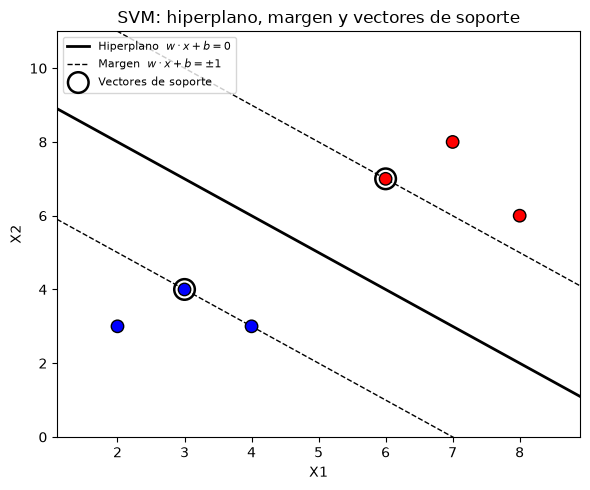

Vector normal w = [0.33333333 0.33333333]
Sesgo b = -3.3333
||w|| = 0.4714
Ancho del margen = 2 / ||w|| = 4.2426


In [ ]:
# Entrenamos un SVM lineal sobre los datos de la Sección 1
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X, y)

def plot_svm(clf, X, y, ax=None, titulo="SVM: hiperplano, margen y vectores de soporte"):
    # Grafica los datos, el hiperplano de decisión, las líneas de margen
    # y resalta los vectores de soporte.
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=80, edgecolors='k', zorder=3)

    w = clf.coef_[0]
    b = clf.intercept_[0]

    # Ecuación del hiperplano despejando x2: w0*x1 + w1*x2 + b = 0  =>  x2 = -(w0*x1 + b)/w1
    x_plot = np.linspace(min(X[:, 0]) - 1, max(X[:, 0]) + 1, 50)
    y_hiperplano = -(w[0] * x_plot + b) / w[1]

    # Líneas de margen: w0*x1 + w1*x2 + b = +1  y  = -1  =>  despejamos x2 directamente
    # (esta forma es equivalente a usar 1/||w|| pero más transparente para verificar a mano)
    y_margen_sup = (1 - w[0] * x_plot - b) / w[1]
    y_margen_inf = (-1 - w[0] * x_plot - b) / w[1]

    ax.plot(x_plot, y_hiperplano, 'k-', lw=2, label='Hiperplano  $w\\cdot x + b = 0$')
    ax.plot(x_plot, y_margen_sup, 'k--', lw=1, label='Margen  $w\\cdot x + b = \\pm 1$')
    ax.plot(x_plot, y_margen_inf, 'k--', lw=1)

    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=220,
               facecolors='none', edgecolors='k', linewidths=1.8, zorder=4,
               label='Vectores de soporte')

    ax.set_title(titulo)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    # Limitamos los ejes al rango de los datos (con margen visual) para que el
    # zoom no dependa de la pendiente de las líneas de margen, que puede ser
    # muy pronunciada cuando w1 es pequeño.
    pad_x = 0.15 * (X[:, 0].max() - X[:, 0].min() + 1e-9)
    pad_y = 0.6 * (X[:, 1].max() - X[:, 1].min() + 1e-9)
    ax.set_xlim(X[:, 0].min() - pad_x, X[:, 0].max() + pad_x)
    ax.set_ylim(X[:, 1].min() - pad_y, X[:, 1].max() + pad_y)
    ax.legend(loc='upper left', fontsize=8)
    return ax

plot_svm(clf, X, y)
plt.tight_layout()
plt.show()

w = clf.coef_[0]
b = clf.intercept_[0]
margen = 2 / np.linalg.norm(w)
print(f"Vector normal w = {w}")
print(f"Sesgo b = {b:.4f}")
print(f"||w|| = {np.linalg.norm(w):.4f}")
print(f"Ancho del margen = 2 / ||w|| = {margen:.4f}")


Observa que el hiperplano encontrado por `sklearn` es, esencialmente, la candidata C que elegimos "a ojo" en la sección 1 — pero ahora sabemos que **no fue una elección arbitraria**: es la única línea que resuelve el problema de optimización $\min \frac12\|w\|^2$ sujeto a las restricciones. Es matemáticamente **la mejor** de todas las líneas posibles.


---
## 3. Vectores de soporte: por qué solo unos pocos puntos importan

Fíjate en la gráfica anterior: solo **algunos** puntos quedaron marcados con un círculo (los vectores de soporte). Son los puntos de entrenamiento que caen **exactamente sobre** la línea de margen, es decir, para los que se cumple:

$$
y_i (w \cdot x_i + b) = 1
$$

Estos puntos son los que "sostienen" el margen — si los movieras, el hiperplano cambiaría. En cambio, si movieras cualquiera de los **otros** puntos (siempre que sigan del lado correcto y fuera del margen), el hiperplano **no cambiaría en absoluto**.

Esta propiedad es una de las razones por las que SVM es un modelo elegante: la solución final depende de un subconjunto pequeño de los datos, no de todos.


In [ ]:
print(f"Número total de puntos de entrenamiento: {len(X)}")
print(f"Número de vectores de soporte: {len(clf.support_vectors_)}")
print(f"Vectores de soporte:\n{clf.support_vectors_}")
print()
print("Verificación: para cada vector de soporte, y_i * (w . x_i + b) debe ser (muy cercano a) 1")
for xi, yi in zip(clf.support_vectors_, y[clf.support_]):
    yi_signo = 1 if yi == 1 else -1
    valor = yi_signo * (np.dot(w, xi) + b)
    print(f"  x_i = {xi},  y_i·(w·x_i + b) = {valor:.4f}")


Número total de puntos de entrenamiento: 6
Número de vectores de soporte: 2
Vectores de soporte:
[[3. 4.]
 [6. 7.]]

Verificación: para cada vector de soporte, y_i * (w . x_i + b) debe ser (muy cercano a) 1
  x_i = [3. 4.],  y_i·(w·x_i + b) = 1.0000
  x_i = [6. 7.],  y_i·(w·x_i + b) = 1.0000


---
## 4. El papel del producto punto en la clasificación

### 🎯 ¿Qué hace el producto punto?

Una vez entrenado el modelo (es decir, una vez que conocemos $w$ y $b$), clasificar un punto nuevo $x$ es muy simple: se calcula

$$
f(x) = w \cdot x + b
$$

- Si $f(x) > 0$: el punto está de un lado (clase $+1$).
- Si $f(x) < 0$: está del otro lado (clase $-1$).
- Si $f(x) = 0$: está exactamente sobre el hiperplano.

El **producto punto** $w \cdot x$ mide la **proyección** de $x$ sobre la dirección $w$: si el ángulo entre ambos vectores es agudo, la proyección (y por tanto $f(x)$) es positiva; si es obtuso, es negativa. En otras palabras, el producto punto convierte la posición del punto en un solo número que nos dice de qué lado está y qué tan lejos.


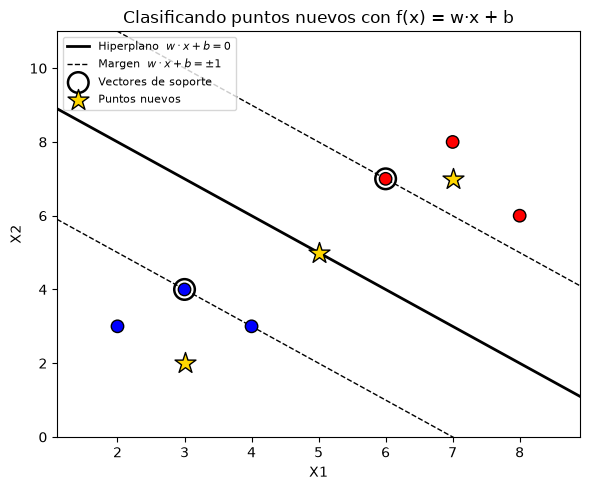

Punto [5 5]: f(x) = w·x + b =   0.00  ->  clase predicha: 1
Punto [7 7]: f(x) = w·x + b =   1.33  ->  clase predicha: 1
Punto [3 2]: f(x) = w·x + b =  -1.67  ->  clase predicha: 0


In [ ]:
# Función de decisión usando el modelo entrenado
def decision_function(x):
    return np.dot(w, x) + b

puntos_prueba = np.array([[5, 5], [7, 7], [3, 2]])

fig, ax = plt.subplots(figsize=(6, 5))
plot_svm(clf, X, y, ax=ax, titulo="Clasificando puntos nuevos con f(x) = w·x + b")
ax.scatter(puntos_prueba[:, 0], puntos_prueba[:, 1], marker='*', s=250,
           c='gold', edgecolors='k', zorder=5, label='Puntos nuevos')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

for punto in puntos_prueba:
    valor = decision_function(punto)
    clase = 1 if valor > 0 else 0
    print(f"Punto {punto}: f(x) = w·x + b = {valor:6.2f}  ->  clase predicha: {clase}")


Nota el caso del punto $[5, 5]$: su valor de $f(x)$ es (casi) cero, es decir, cae **justo sobre el hiperplano**. Es el caso más ambiguo posible — el modelo no tiene ninguna confianza en su predicción para ese punto, algo que el valor de $f(x)$ nos deja ver directamente (no solo el signo, sino la magnitud).

### 🔁 De la forma primal a la forma dual

Durante el entrenamiento, SVM en realidad resuelve un problema equivalente (llamado **problema dual**) en el que la solución óptima $w$ se expresa como una **combinación lineal de los vectores de soporte**:

$$
w = \sum_{i=1}^{N} \alpha_i y_i x_i
$$

donde $\alpha_i > 0$ solo para los vectores de soporte (para el resto de los puntos, $\alpha_i = 0$ — esto formaliza lo que vimos en la Sección 3). Sustituyendo, la función de decisión queda:

$$
f(x) = \sum_{i=1}^{N} \alpha_i y_i (x_i \cdot x) + b
$$

🔸 **Este es el punto más importante de todo el notebook:** en esta formulación, los datos $x_i$ y $x$ **nunca aparecen solos**, siempre aparecen dentro de un producto punto $x_i \cdot x$. Esta observación es la puerta de entrada al truco del kernel que veremos en la Sección 6.


---
## 5. El parámetro `C`: margen duro vs. margen blando

Hasta ahora asumimos que los datos son **perfectamente separables**. En la práctica, casi nunca lo son: suele haber ruido o puntos atípicos que se "meten" del lado equivocado. Si exigiéramos una separación perfecta (margen duro), el modelo podría:

- No encontrar ninguna solución (si los datos no son separables), o
- Encontrar un margen muy angosto, sobreajustado a un par de puntos ruidosos.

Para resolver esto, SVM introduce variables de holgura $\xi_i \ge 0$ que permiten que algunos puntos violen el margen, penalizando esa violación en la función objetivo:

$$
\min_{w,\, b,\, \xi} \quad \frac{1}{2}\|w\|^2 + C \sum_{i=1}^N \xi_i
\qquad \text{sujeto a} \qquad y_i(w\cdot x_i + b) \ge 1 - \xi_i,\quad \xi_i \ge 0
$$

El hiperparámetro **`C` controla el compromiso** entre dos objetivos que compiten:

| `C` | Efecto | Riesgo |
|---|---|---|
| **Pequeño** | Margen más ancho, tolera más violaciones | Puede subajustar (*underfitting*) |
| **Grande** | Margen más angosto, penaliza fuerte cada violación | Puede sobreajustar (*overfitting*) al ruido |

Veámoslo con datos que tienen un poco de ruido (algunos puntos "cruzados" hacia el lado equivocado):


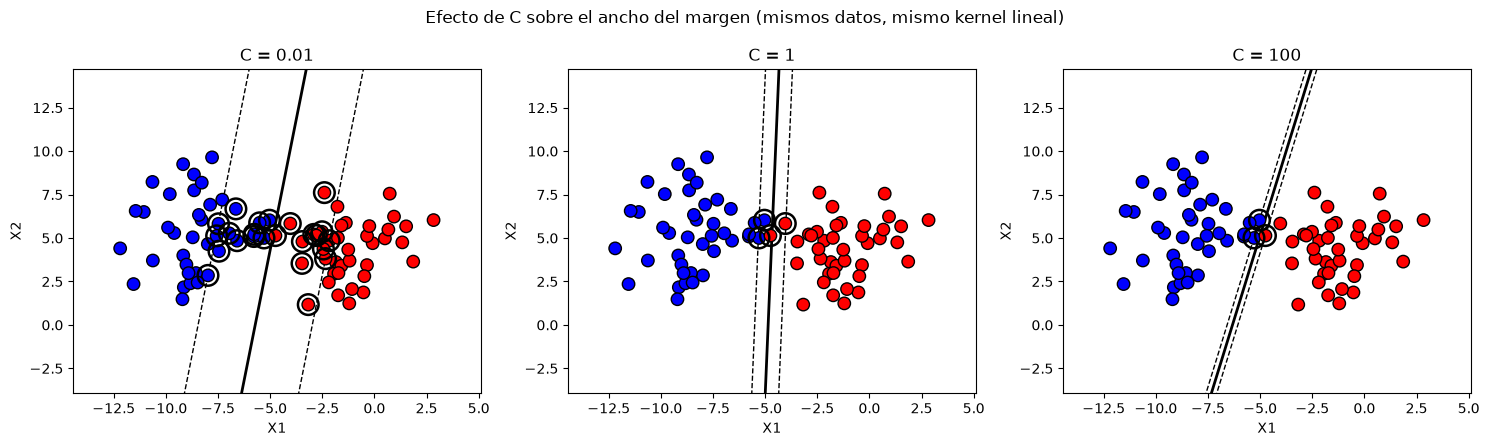

Observa cómo, a medida que C crece, el margen se vuelve más angosto
y el modelo se ajusta más agresivamente a cada punto individual.


In [ ]:
from sklearn.datasets import make_blobs

X_ruido, y_ruido = make_blobs(n_samples=80, centers=2, cluster_std=1.8, random_state=7)

valores_C = [0.01, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, C_val in zip(axes, valores_C):
    modelo = svm.SVC(kernel='linear', C=C_val)
    modelo.fit(X_ruido, y_ruido)
    plot_svm(modelo, X_ruido, y_ruido, ax=ax, titulo=f"C = {C_val}")
    ax.legend().remove()

plt.suptitle("Efecto de C sobre el ancho del margen (mismos datos, mismo kernel lineal)")
plt.tight_layout()
plt.show()

print("Observa cómo, a medida que C crece, el margen se vuelve más angosto")
print("y el modelo se ajusta más agresivamente a cada punto individual.")


---
## 6. Datos no separables linealmente

### El problema

Imagina datos distribuidos como **dos círculos concéntricos**: una clase forma un anillo interior y la otra un anillo exterior. Es imposible trazar una sola línea recta que separe ambas clases — sin importar cuánto ajustemos `C`, ningún hiperplano lineal va a funcionar bien, porque el problema en sí no es lineal.


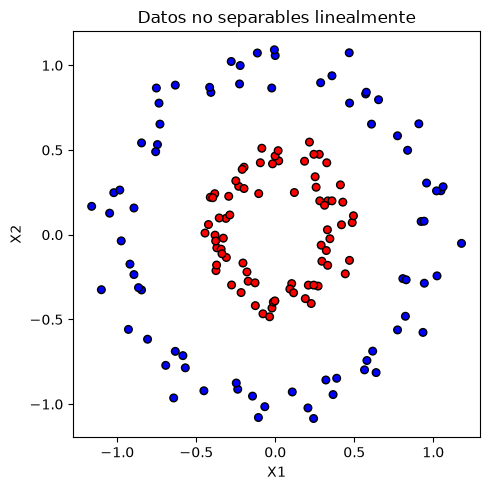

Exactitud de un SVM lineal sobre estos datos: 59.33%
Un solo hiperplano no puede separar un círculo interno de uno externo.


In [ ]:
from sklearn.datasets import make_circles
from sklearn.svm import SVC

X_circ, y_circ = make_circles(n_samples=150, factor=0.4, noise=0.08, random_state=42)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap='bwr', s=30, edgecolors='k')
ax.set_title("Datos no separables linealmente")
ax.set_xlabel("X1"); ax.set_ylabel("X2")
plt.tight_layout()
plt.show()

svm_lineal_circ = SVC(kernel='linear').fit(X_circ, y_circ)
print(f"Exactitud de un SVM lineal sobre estos datos: {svm_lineal_circ.score(X_circ, y_circ):.2%}")
print("Un solo hiperplano no puede separar un círculo interno de uno externo.")


### La solución conceptual: cambiar de espacio

La idea es transformar los datos con una función de mapeo $\phi(x)$ que los proyecte a un espacio de mayor dimensión donde **sí** sean linealmente separables. Por ejemplo, mapear un punto $(x_1, x_2)$ a $(x_1,\, x_2,\, x_1^2 + x_2^2)$ convierte los dos círculos en dos "tazones" (paraboloides) a distinta altura, que ahora sí se pueden separar con un plano.

**El problema práctico:** calcular $\phi(x)$ explícitamente puede ser muy costoso — en algunos casos el espacio transformado tiene miles, o incluso **infinitas**, dimensiones. Necesitamos una forma de obtener los beneficios de esa transformación sin pagar su costo computacional.


---
## 7. El truco del kernel

Recordemos el hallazgo clave de la Sección 4: en la formulación dual de SVM, los datos **solo aparecen dentro de un producto punto**:

$$
f(x) = \sum_{i=1}^{N} \alpha_i y_i (x_i \cdot x) + b
$$

Esto significa que el algoritmo **nunca necesita conocer las coordenadas de $x_i$ por separado** — solo necesita el resultado de $x_i \cdot x_j$ para cada par de puntos.

Entonces, ¿qué pasa si, en vez de calcular $\phi(x_i) \cdot \phi(x_j)$ transformando explícitamente los datos, encontramos una función que nos dé **directamente** ese mismo resultado, sin pasar por $\phi$?

**Definición de kernel:** una función $K$ que toma dos vectores del espacio original y devuelve el producto punto de sus imágenes en el espacio transformado:

$$
K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)
$$

El "truco" consiste en calcular el lado izquierdo (barato, directo sobre los datos originales) en vez del lado derecho (caro, requiere construir $\phi$). El resultado numérico es **idéntico** — lo comprobaremos con un ejemplo concreto en la siguiente sección.


---
## 8. Kernel polinómico: ejemplo numérico completo

El **kernel polinómico** de grado $d$ se define como:

$$
K(x_i, x_j) = (\langle x_i, x_j \rangle + c)^d
$$

- $\langle x_i, x_j \rangle$ es el producto punto en el espacio original.
- $c$ es un coeficiente libre (aquí usamos $c = 0$).
- $d$ es el grado del polinomio.

Con $d = 2$ y $c = 0$, el kernel se simplifica a:

$$
K(x_i, x_j) = (\langle x_i, x_j \rangle)^2
$$

### ✏️ Ejemplo paso a paso

Tomemos dos vectores en 2 dimensiones:

$$
x_i = [1,\ 2] \qquad x_j = [3,\ 4]
$$

**Paso 1 — producto punto en el espacio original:**

$$
\langle x_i, x_j \rangle = (1)(3) + (2)(4) = 3 + 8 = 11
$$

**Paso 2 — aplicar el kernel polinómico de grado 2:**

$$
K(x_i, x_j) = (11)^2 = 121
$$

¡Listo! Ya usamos el truco del kernel sin transformar nada explícitamente. Ahora vamos a comprobar que este resultado coincide exactamente con transformar los datos "a mano" y calcular el producto punto en el espacio transformado.

### ¿Qué transformación $\phi(x)$ corresponde a este kernel?

Se puede demostrar algebraicamente que el kernel polinómico de grado 2 (con $c=0$) sobre vectores 2D es equivalente a la siguiente transformación explícita:

$$
\phi(x) = \left[\, x_1^2,\ \ \sqrt{2}\, x_1 x_2,\ \ x_2^2 \,\right]
$$

Es decir, $\phi$ agrega los cuadrados de cada característica y su producto cruzado (con un factor $\sqrt{2}$ que aparece naturalmente al expandir $(\langle x_i, x_j\rangle)^2$ con el binomio de Newton). Calculemos $\phi(x_i)$ y $\phi(x_j)$:

$$
\phi(x_i) = [1^2,\ \sqrt{2}\cdot 1\cdot 2,\ 2^2] = [1,\ 2\sqrt{2},\ 4]
$$

$$
\phi(x_j) = [3^2,\ \sqrt{2}\cdot 3\cdot 4,\ 4^2] = [9,\ 12\sqrt{2},\ 16]
$$

Y su producto punto **en el espacio transformado**:

$$
\phi(x_i) \cdot \phi(x_j) = (1)(9) + (2\sqrt{2})(12\sqrt{2}) + (4)(16) = 9 + 48 + 64 = 121
$$

**¡El mismo valor que obtuvimos con el kernel, sin construir $\phi$!** Verifiquémoslo en código:


In [ ]:
x_i = np.array([1, 2])
x_j = np.array([3, 4])

# --- Camino 1: el truco del kernel (barato) ---
dot_product = np.dot(x_i, x_j)
kernel_poly = dot_product ** 2
print(f"Paso 1 — producto punto en el espacio original: <x_i, x_j> = {dot_product}")
print(f"Paso 2 — kernel polinómico grado 2:            K(x_i, x_j) = {kernel_poly}")

# --- Camino 2: transformación explícita (costosa) ---
def phi(x):
    return np.array([x[0]**2, np.sqrt(2) * x[0] * x[1], x[1]**2])

phi_xi = phi(x_i)
phi_xj = phi(x_j)
dot_phi = np.dot(phi_xi, phi_xj)

print()
print(f"phi(x_i) = {phi_xi}")
print(f"phi(x_j) = {phi_xj}")
print(f"Producto punto en el espacio transformado: phi(x_i)·phi(x_j) = {dot_phi}")
print()
assert np.isclose(kernel_poly, dot_phi), "¡Los dos caminos deberían coincidir!"
print("Verificado: ambos caminos dan exactamente el mismo resultado ✅")


Paso 1 — producto punto en el espacio original: <x_i, x_j> = 11
Paso 2 — kernel polinómico grado 2:            K(x_i, x_j) = 121

phi(x_i) = [1.         2.82842712 4.        ]
phi(x_j) = [ 9.         16.97056275 16.        ]
Producto punto en el espacio transformado: phi(x_i)·phi(x_j) = 121.0

Verificado: ambos caminos dan exactamente el mismo resultado ✅


### Visualizando la transformación

Para terminar de interiorizar la idea, generemos un conjunto de datos 2D donde las dos clases **no** son separables por una línea que pase por el origen, apliquemos $\phi(x)$ explícitamente, y veamos cómo se ven en el espacio transformado 3D.


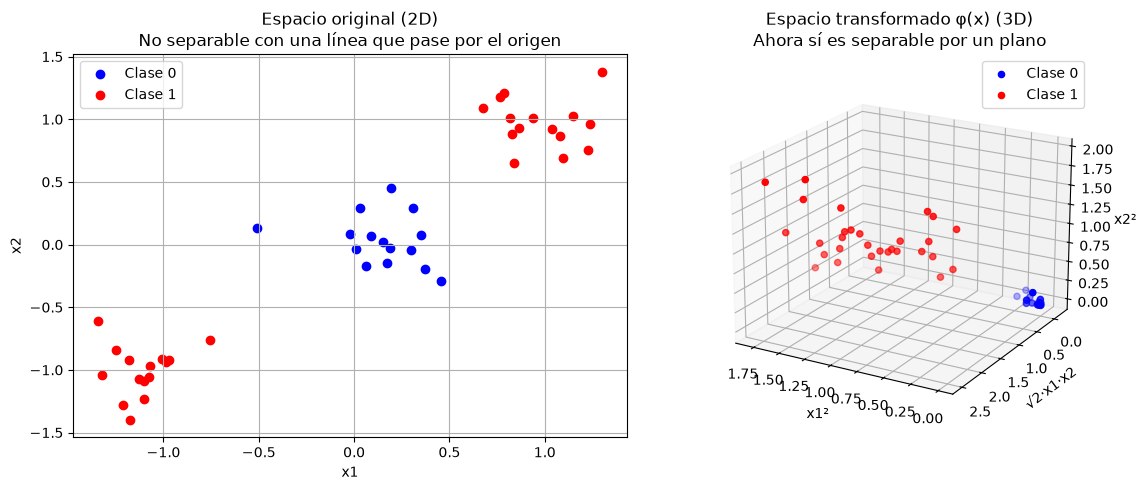

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(0)
sigma = 0.2
X_c1 = sigma * np.random.randn(15, 2) + np.array([0, 0])          # clase 0: alrededor del origen
X_c2 = np.vstack([
    sigma * np.random.randn(15, 2) + np.array([-1, -1]),
    sigma * np.random.randn(15, 2) + np.array([1, 1]),
])                                                                  # clase 1: dos nubes opuestas

X_phi_demo = np.vstack([X_c1, X_c2])
y_phi_demo = np.hstack([np.zeros(15), np.ones(30)])

def phi_polinomial_2d(x):
    # Transformación explícita del kernel polinomial de grado 2: [x1^2, sqrt(2) x1 x2, x2^2]
    x1, x2 = x[:, 0], x[:, 1]
    return np.vstack([x1**2, np.sqrt(2) * x1 * x2, x2**2]).T

X_transformado = phi_polinomial_2d(X_phi_demo)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X_phi_demo[y_phi_demo == 0, 0], X_phi_demo[y_phi_demo == 0, 1], color='blue', label='Clase 0')
ax1.scatter(X_phi_demo[y_phi_demo == 1, 0], X_phi_demo[y_phi_demo == 1, 1], color='red', label='Clase 1')
ax1.set_title("Espacio original (2D)\nNo separable con una línea que pase por el origen")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2")
ax1.legend(); ax1.grid(True)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_transformado[y_phi_demo == 0, 0], X_transformado[y_phi_demo == 0, 1], X_transformado[y_phi_demo == 0, 2],
            color='blue', label='Clase 0')
ax2.scatter(X_transformado[y_phi_demo == 1, 0], X_transformado[y_phi_demo == 1, 1], X_transformado[y_phi_demo == 1, 2],
            color='red', label='Clase 1')
ax2.set_title("Espacio transformado φ(x) (3D)\nAhora sí es separable por un plano")
ax2.set_xlabel("x1²"); ax2.set_ylabel("√2·x1·x2"); ax2.set_zlabel("x2²")
ax2.legend()
ax2.view_init(elev=20, azim=120)

plt.tight_layout()
plt.show()


Ahora comparemos, sobre los datos de los **círculos concéntricos**, un SVM con kernel lineal (que ya vimos que falla) contra un SVM con kernel polinómico:


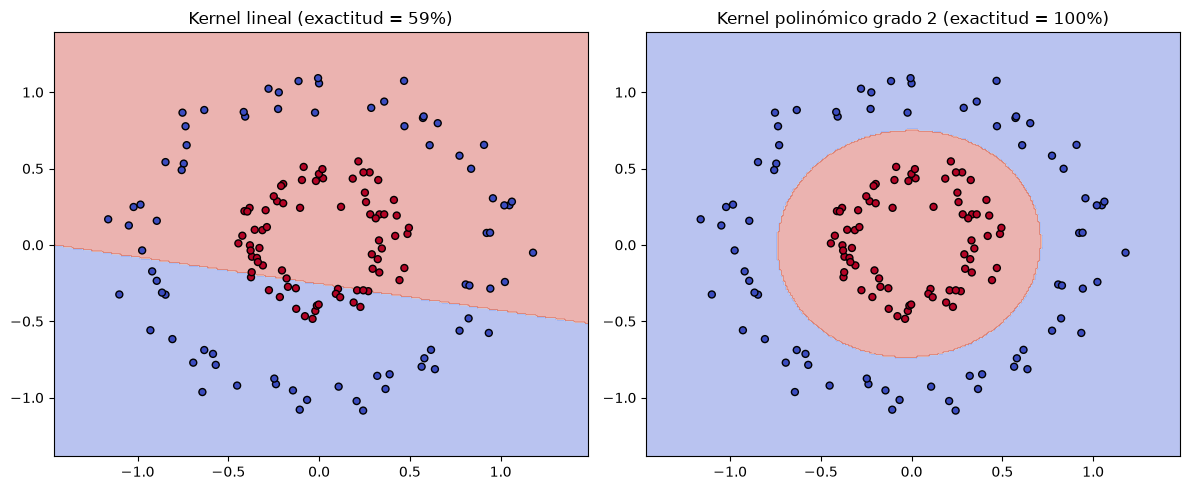

In [ ]:
svm_poly_circ = SVC(kernel='poly', degree=2, coef0=1).fit(X_circ, y_circ)

def plot_frontera_decision(model, X, y, ax, titulo):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=25, edgecolor='k', cmap=plt.cm.coolwarm)
    ax.set_title(titulo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_frontera_decision(svm_lineal_circ, X_circ, y_circ, axes[0],
                        f"Kernel lineal (exactitud = {svm_lineal_circ.score(X_circ, y_circ):.0%})")
plot_frontera_decision(svm_poly_circ, X_circ, y_circ, axes[1],
                        f"Kernel polinómico grado 2 (exactitud = {svm_poly_circ.score(X_circ, y_circ):.0%})")
plt.tight_layout()
plt.show()


---
## 9. Kernel de Base Radial (RBF / Gaussiano)

El kernel polinómico funciona bien, pero nos obliga a elegir de antemano un grado $d$. ¿Qué pasa si la frontera de decisión ideal no tiene forma de polinomio simple? El **kernel RBF** (también llamado Gaussiano) ofrece mucha más flexibilidad porque, como veremos, corresponde a un espacio transformado de **dimensión infinita**.

### ✅ Fórmula

$$
K(x_i, x_j) = \exp\left(-\gamma \, \|x_i - x_j\|^2\right)
$$

donde $\|x_i - x_j\|^2$ es la distancia euclidiana al cuadrado entre los dos puntos, y $\gamma > 0$ controla qué tan "localizada" es la influencia de cada punto:

- $\gamma$ **grande** → la influencia de cada punto decae muy rápido con la distancia (solo importan los vecinos muy cercanos).
- $\gamma$ **pequeño** → la influencia se extiende lejos (comportamiento más suave, más parecido a un kernel lineal).

🔑 **Intuición:** el kernel RBF es una medida de *similitud*. Dos puntos muy cercanos tienen $K \approx 1$ (muy similares); dos puntos lejanos tienen $K \approx 0$ (casi nada en común).

### 🧮 ¿Por qué genera un espacio de dimensión infinita?

La respuesta está en la expansión en **serie de Taylor** de la función exponencial: $e^z = \sum_{k=0}^{\infty} \dfrac{z^k}{k!}$.

**Paso 1.** Expandimos la distancia al cuadrado dentro del kernel:

$$
K(x_i, x_j) = \exp\Big(-\gamma\big(\|x_i\|^2 - 2\, x_i\cdot x_j + \|x_j\|^2\big)\Big)
$$

**Paso 2.** Separamos la exponencial en tres factores:

$$
K(x_i, x_j) = \underbrace{\exp(-\gamma\|x_i\|^2)}_{\text{constante en } x_i} \cdot \underbrace{\exp(-\gamma\|x_j\|^2)}_{\text{constante en } x_j} \cdot \exp\big(2\gamma\, x_i \cdot x_j\big)
$$

Los dos primeros factores son solo escalares (no dependen de la interacción entre $x_i$ y $x_j$); el término interesante es el tercero.

**Paso 3.** Aplicamos la serie de Taylor al término interesante, con $z = 2\gamma\, x_i\cdot x_j$:

$$
\exp\big(2\gamma\, x_i \cdot x_j\big) = \sum_{k=0}^{\infty} \frac{\big(2\gamma\, x_i\cdot x_j\big)^k}{k!} = \sum_{k=0}^{\infty} \frac{(2\gamma)^k}{k!} \,\big(x_i \cdot x_j\big)^k
$$

**Paso 4.** ¡Observa el término $(x_i \cdot x_j)^k$! Es, exactamente, un **kernel polinómico de grado $k$**.

**Conclusión:** el kernel RBF es una **suma ponderada infinita de kernels polinomiales de todos los grados posibles** ($k = 0, 1, 2, 3, \dots$). Como cada kernel polinómico de grado $k$ corresponde a un producto punto en un espacio de características de dimensión finita (pero creciente con $k$), sumar infinitos de estos kernels equivale a trabajar en un espacio $\phi$ de **dimensión infinita**. El truco del kernel nos permite usar ese espacio infinito sin jamás construirlo explícitamente — solo evaluamos la fórmula cerrada $\exp(-\gamma\|x_i-x_j\|^2)$.


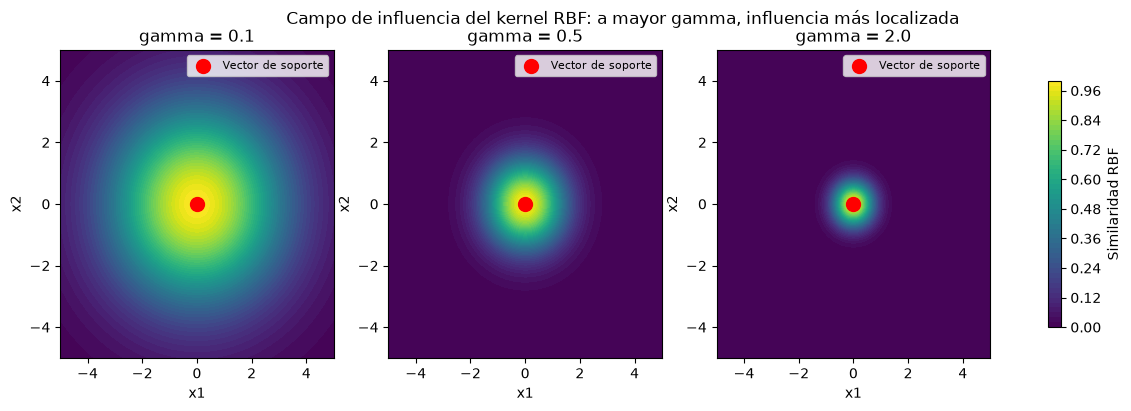

In [ ]:
# Visualicemos el "campo de influencia" del kernel RBF alrededor de un único punto
x_min, x_max, y_min_, y_max_ = -5, 5, -5, 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min_, y_max_, 150))
puntos_grid = np.c_[xx.ravel(), yy.ravel()]

x_soporte = np.array([0, 0])

def rbf_kernel(x, centro, gamma=0.5):
    dist_cuadrada = np.sum((x - centro) ** 2, axis=1)
    return np.exp(-gamma * dist_cuadrada)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, gamma_val in zip(axes, [0.1, 0.5, 2.0]):
    similitud = rbf_kernel(puntos_grid, x_soporte, gamma=gamma_val).reshape(xx.shape)
    cf = ax.contourf(xx, yy, similitud, levels=50, cmap='viridis')
    ax.scatter(*x_soporte, color='red', s=100, label='Vector de soporte')
    ax.set_title(f'gamma = {gamma_val}')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(loc='upper right', fontsize=8)

fig.colorbar(cf, ax=axes, label='Similaridad RBF', shrink=0.8)
plt.suptitle("Campo de influencia del kernel RBF: a mayor gamma, influencia más localizada")
plt.show()


El punto rojo es el vector de soporte. Las zonas más claras (amarillo/verde) indican **alta similitud** con ese punto; las zonas oscuras (azul), **baja similitud**. Nota cómo, al aumentar `gamma`, el "halo" de influencia se encoge: el kernel se vuelve más sensible a la cercanía exacta.

### Efecto de `gamma` sobre la frontera de decisión

Veamos ahora el efecto real sobre un problema de clasificación (`make_moons`), comparando varios valores de `gamma`:


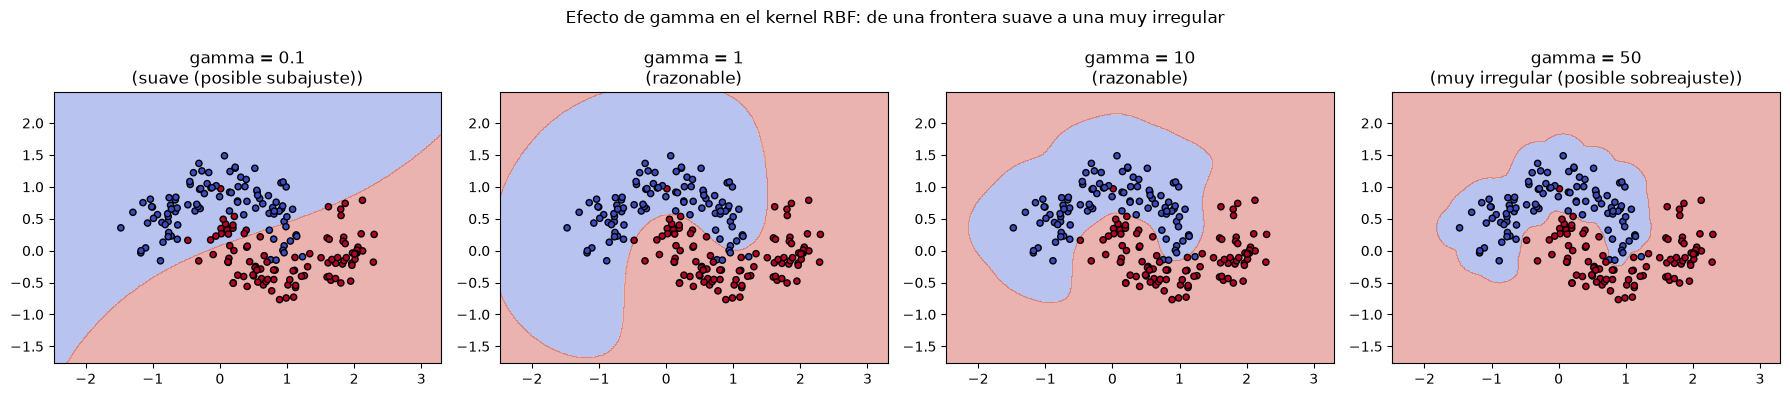

In [ ]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=200, noise=0.2, random_state=42)

def plot_frontera_moons(model, X, y, ax, titulo):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=20)
    ax.set_title(titulo)
    ax.set_xlim(xx.min(), xx.max()); ax.set_ylim(yy.min(), yy.max())

gammas = [0.1, 1, 10, 50]
fig, axes = plt.subplots(1, len(gammas), figsize=(18, 4))
for ax, gamma_val in zip(axes, gammas):
    modelo = SVC(kernel='rbf', gamma=gamma_val, C=1).fit(X_moons, y_moons)
    etiqueta = "suave (posible subajuste)" if gamma_val <= 0.1 else (
               "muy irregular (posible sobreajuste)" if gamma_val >= 50 else "razonable")
    plot_frontera_moons(modelo, X_moons, y_moons, ax, f"gamma = {gamma_val}\n({etiqueta})")

plt.suptitle("Efecto de gamma en el kernel RBF: de una frontera suave a una muy irregular")
plt.tight_layout()
plt.show()


Con `gamma` pequeño la frontera es casi lineal (cada punto "ve" muy lejos, así que el modelo promedia mucho y puede subajustar). Con `gamma` muy grande, la frontera se vuelve tan irregular que prácticamente rodea cada punto individual — el modelo memoriza el ruido de entrenamiento en vez de aprender un patrón general (sobreajuste). Igual que con `C`, `gamma` es un hiperparámetro que se debe ajustar (por ejemplo, con validación cruzada), no fijar arbitrariamente.


---
## 10. Consolidado de conceptos

| Concepto | Intuición |
|---|---|
| **Producto punto en el espacio original** | Compara directamente las características lineales de dos puntos. |
| **Margen** | El "ancho de la calle" entre las clases; SVM lo maximiza minimizando $\|w\|$. |
| **Vectores de soporte** | Los únicos puntos que determinan el hiperplano; el resto no importa. |
| **Parámetro `C`** | Controla qué tan estrictamente se penaliza violar el margen (subajuste vs. sobreajuste). |
| **Espacio transformado $\phi(x)$** | Crea nuevas combinaciones de características (no lineales) donde los datos sí son separables. |
| **Kernel** | Calcula el producto punto en ese espacio transformado **sin construir $\phi(x)$** explícitamente. |
| **Kernel polinómico** | Equivale a un espacio con potencias y productos cruzados de las características, hasta el grado $d$. |
| **Kernel RBF** | Equivale a una suma infinita de kernels polinomiales; controla la localidad con `gamma`. |

| Kernel | ¿Cuándo usarlo? |
|---|---|
| **Lineal** | Datos separables (o casi) por una línea/plano. Rápido, pocos hiperparámetros. |
| **Polinómico** | Fronteras curvas "moderadas"; se sabe (o se sospecha) el grado de interacción entre variables. |
| **RBF (Gaussiano)** | Fronteras muy flexibles, sin conocer su forma de antemano. Es la opción por defecto más común. |


---
## 11. SVM para regresión (SVR)

Todo lo anterior fue para **clasificación**. La misma idea se puede adaptar a **regresión**: en vez de buscar un hiperplano que separe clases, buscamos una función $f(x)$ que **aproxime** los datos, permitiendo un margen de tolerancia $\epsilon$ (un "tubo") dentro del cual los errores no se penalizan.

### ⚙️ Formalismo básico

SVR busca $f(x)$ tal que, para la mayoría de los puntos:

$$
|y_i - f(x_i)| \le \epsilon
$$

y, al mismo tiempo, minimiza la complejidad de $w$ (igual que en el caso de clasificación). Los puntos que caen **fuera** del tubo de ancho $2\epsilon$ sí pagan un costo, proporcional a `C` — el mismo hiperparámetro que vimos en la Sección 5.


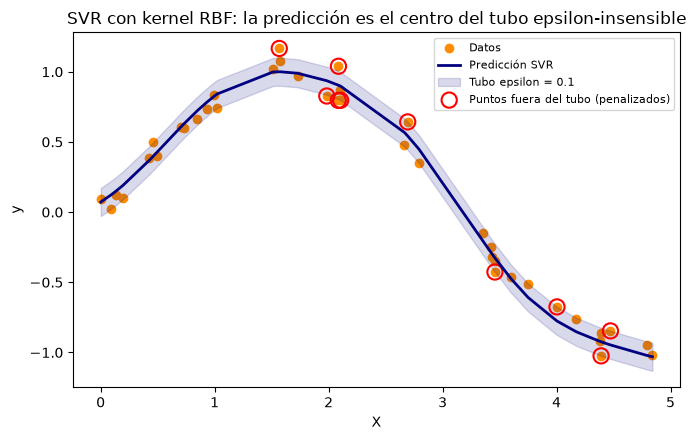

Puntos totales: 40  |  Puntos fuera del tubo epsilon: 10


In [ ]:
from sklearn.svm import SVR

np.random.seed(1)
X_reg = np.sort(5 * np.random.rand(40, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.randn(*X_reg.shape).ravel() * 0.1

epsilon = 0.1
svr_rbf = SVR(kernel='rbf', C=100, epsilon=epsilon).fit(X_reg, y_reg)
y_pred = svr_rbf.predict(X_reg)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_reg, y_reg, color='darkorange', label='Datos')
ax.plot(X_reg, y_pred, color='navy', lw=2, label='Predicción SVR')
ax.fill_between(X_reg.ravel(), y_pred - epsilon, y_pred + epsilon,
                 color='navy', alpha=0.15, label=f'Tubo epsilon = {epsilon}')

# Puntos que caen fuera del tubo epsilon (estos son análogos a los "vectores de soporte")
fuera_del_tubo = np.abs(y_reg - y_pred) > epsilon
ax.scatter(X_reg[fuera_del_tubo], y_reg[fuera_del_tubo], facecolors='none',
           edgecolors='red', s=120, linewidths=1.5, label='Puntos fuera del tubo (penalizados)')

ax.set_title("SVR con kernel RBF: la predicción es el centro del tubo epsilon-insensible")
ax.set_xlabel("X"); ax.set_ylabel("y")
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Puntos totales: {len(X_reg)}  |  Puntos fuera del tubo epsilon: {fuera_del_tubo.sum()}")


El área sombreada es el **tubo $\epsilon$-insensible**: cualquier punto dentro de esa banda no genera penalización, sin importar qué tan lejos esté exactamente de la curva. Solo los puntos que quedan fuera del tubo (marcados en rojo) contribuyen al costo del modelo — son el análogo, en regresión, a los vectores de soporte de la clasificación.


---
## 12. Ejercicios propuestos

Resuelve los siguientes ejercicios para consolidar los conceptos de este notebook. Se recomienda reutilizar y modificar las funciones ya definidas (`plot_svm`, `plot_frontera_decision`, `plot_frontera_moons`).

1. **Margen y vectores de soporte.** Añade un punto nuevo a los datos de la Sección 1 que quede *dentro* del margen actual (por ejemplo, cerca de $(5, 5)$) y vuelve a entrenar el SVM lineal. ¿Cambiaron $w$, $b$ y el conjunto de vectores de soporte? Explica por qué, con tus propias palabras, usando lo visto en la Sección 3.

2. **El parámetro `C`.** Usando `X_ruido, y_ruido` de la Sección 5, entrena modelos con `C` en `[0.001, 0.1, 1, 10, 1000]` y grafica, para cada uno, el número de vectores de soporte (`len(modelo.support_vectors_)`) contra `C`. ¿Qué relación observas? ¿Por qué tiene sentido a la luz del problema de optimización de la Sección 5?

3. **Verificación de un kernel a mano.** Repite el procedimiento de la Sección 8 (kernel polinómico) pero con los vectores $x_i = [2, -1]$ y $x_j = [0, 3]$, y grado $d=3$ (usa $c=0$). Calcula $K(x_i, x_j)$ directamente con la fórmula, y verifica el resultado en código.

4. **Comparación de kernels.** Sobre los datos de `make_moons` (Sección 9), entrena tres modelos — `kernel='linear'`, `kernel='poly'` (grado 3) y `kernel='rbf'` — y compara sus fronteras de decisión y su exactitud (`.score`). ¿Cuál kernel es más adecuado para este problema y por qué?

5. **SVR y el ancho del tubo.** Repite el ejemplo de la Sección 11 variando `epsilon` en `[0.01, 0.1, 0.5]`, manteniendo `C=100` fijo. ¿Qué le pasa al número de puntos "fuera del tubo" a medida que `epsilon` crece? ¿Cómo cambiaría tu respuesta si en cambio variaras `C` y dejaras `epsilon` fijo?

6. **Pregunta conceptual (sin código).** Explica, en un párrafo, por qué el truco del kernel sería inútil si la función de decisión de SVM dependiera de las coordenadas individuales de $x_i$ en lugar de depender solo de productos punto $x_i \cdot x_j$.


---
### ✅ Solución detallada de los ejercicios

A continuación resolvemos, uno por uno, los seis ejercicios propuestos. Cada ejercicio tiene su código y, justo después, la interpretación de los resultados con números concretos. Se reutilizan las variables y funciones ya definidas en el notebook:

| Variable / función | Sección de origen |
|---|---|
| `X`, `y`, `clf`, `plot_svm` | Secciones 1–3 |
| `X_ruido`, `y_ruido` | Sección 5 |
| `X_moons`, `y_moons`, `plot_frontera_moons` | Sección 9 |
| `X_reg`, `y_reg`, `SVR` | Sección 11 |

---
#### Ejercicio 1 — Margen y vectores de soporte


Modelo original: f(5,5) = 0.0000  ->  |f(5,5)| < 1, el punto cae DENTRO de la calle de margen



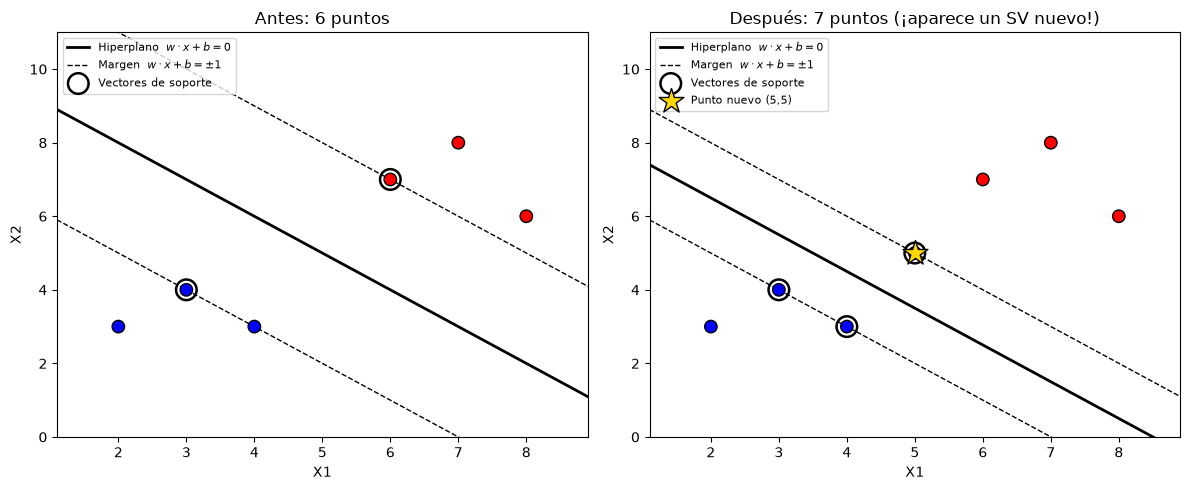

Magnitud                                       Antes               Después
--------------------------------------------------------------------------
w                                    [0.3333 0.3333]       [0.6664 0.6668]
b                                            -3.3333               -5.6661
||w||                                         0.4714                0.9427
ancho del margen 2/||w||                      4.2426                2.1215
# de vectores de soporte                           2                     3
índices de los SV                              [1 3]               [1 2 6]

Vectores de soporte ANTES:
 [[3. 4.]
 [6. 7.]]

Vectores de soporte DESPUÉS:
 [[3. 4.]
 [4. 3.]
 [5. 5.]]


In [ ]:
# ---------- Ejercicio 1: añadir un punto DENTRO del margen ----------
# Estado original del modelo (Sección 2)
w_orig, b_orig = clf.coef_[0], clf.intercept_[0]
margen_orig = 2 / np.linalg.norm(w_orig)

# ¿Dónde queda (5,5) respecto del modelo original?
valor_original = np.dot(w_orig, [5, 5]) + b_orig
print(f"Modelo original: f(5,5) = {valor_original:.4f}  ->  |f(5,5)| < 1, "
      f"el punto cae DENTRO de la calle de margen\n")

# Añadimos el punto (5,5). El modelo original da f(5,5)=0 (justo sobre el
# hiperplano), así que la etiqueta 1 es la que predice; la usamos.
X_ext = np.vstack([X, [[5, 5]]])
y_ext = np.hstack([y, [1]])

clf_ext = svm.SVC(kernel='linear', C=1).fit(X_ext, y_ext)
w_nue, b_nue = clf_ext.coef_[0], clf_ext.intercept_[0]
margen_nue = 2 / np.linalg.norm(w_nue)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_svm(clf, X, y, ax=axes[0], titulo="Antes: 6 puntos")
plot_svm(clf_ext, X_ext, y_ext, ax=axes[1], titulo="Después: 7 puntos (¡aparece un SV nuevo!)")
axes[1].scatter(5, 5, marker='*', s=350, c='gold', edgecolors='k', zorder=6,
                label='Punto nuevo (5,5)')
axes[1].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Tabla comparativa "antes / después"
print(f"{'Magnitud':<30}{'Antes':>22}{'Después':>22}")
print("-" * 74)
print(f"{'w':<30}{str(np.round(w_orig, 4)):>22}{str(np.round(w_nue, 4)):>22}")
print(f"{'b':<30}{b_orig:>22.4f}{b_nue:>22.4f}")
print(f"{'||w||':<30}{np.linalg.norm(w_orig):>22.4f}{np.linalg.norm(w_nue):>22.4f}")
print(f"{'ancho del margen 2/||w||':<30}{margen_orig:>22.4f}{margen_nue:>22.4f}")
print(f"{'# de vectores de soporte':<30}{len(clf.support_):>22}{len(clf_ext.support_):>22}")
print(f"{'índices de los SV':<30}{str(clf.support_):>22}{str(clf_ext.support_):>22}")
print("\nVectores de soporte ANTES:\n", clf.support_vectors_)
print("\nVectores de soporte DESPUÉS:\n", clf_ext.support_vectors_)


**Respuesta (Ejercicio 1).** Sí, cambiaron **todas** las cantidades:

| Magnitud | Antes | Después |
|---|---|---|
| $w$ | $[0.3333,\ 0.3333]$ | $[0.6664,\ 0.6668]$ |
| $b$ | $-3.3333$ | $-5.6661$ |
| $\|w\|$ | $0.4714$ | $0.9427$ |
| Ancho del margen $2/\|w\|$ | $4.2426$ | $2.1215$ |
| Vectores de soporte | 2 → $[3,4]$ y $[6,7]$ | 3 → $[3,4]$, $[4,3]$ y $[5,5]$ |

**¿Por qué?** El punto $(5,5)$ cumple $f(5,5) = 0$, es decir $y_i(w\cdot x_i+b) = 0 < 1$: **viola la restricción del margen** (cae dentro de la "calle"). El problema de optimización de la Sección 2 no puede ignorarlo — debe reacomodar $w$ y $b$ para que, de ser posible, $(5,5)$ quede fuera del margen. Al hacerlo, el hiperplano rota y se desplaza, y el precio es que **la calle se estrecha de 4.24 a 2.12** (un $\|w\|$ mayor, ya que margen $=2/\|w\|$).

Justo después de reentrenar, $(5,5)$ queda **sobre la nueva línea de margen**, así que se convierte en vector de soporte; al mismo tiempo entra $[4,3]$ y sale $[6,7]$. Es la demostración práctica de la Sección 3:

- Solo los puntos que tocan el margen (los SV) **sostienen** la solución: aquí basta con insertar **un** punto en la calle para que $w$, $b$ y todo el conjunto de SV cambien.
- Los puntos que no son SV ($[2,3]$, $[7,8]$, $[8,6]$) siguieron sin serlo: moverlos un poco **no alteraría** la solución.


---
#### Ejercicio 2 — El parámetro `C`


C           # de vectores de soporte     Exactitud (entrenamiento)
------------------------------------------------------------------
0.001                       66 / 80                       100.00%
0.1                         10 / 80                        98.75%
1                            4 / 80                        98.75%
10                           3 / 80                       100.00%
1000                         3 / 80                       100.00%


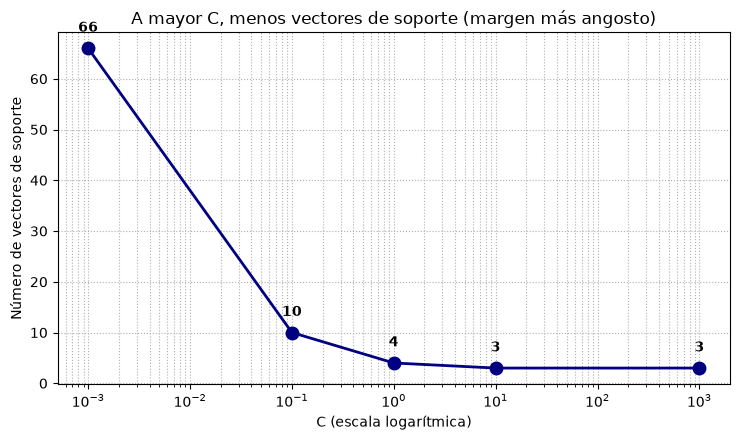

In [ ]:
# ---------- Ejercicio 2: número de vectores de soporte vs. C ----------
Cs = [0.001, 0.1, 1, 10, 1000]
n_sv, exactitudes = [], []

print(f"{'C':<10}{'# de vectores de soporte':>26}{'Exactitud (entrenamiento)':>30}")
print("-" * 66)
for C_val in Cs:
    modelo = svm.SVC(kernel='linear', C=C_val).fit(X_ruido, y_ruido)
    n_sv.append(len(modelo.support_vectors_))
    exactitudes.append(modelo.score(X_ruido, y_ruido))
    print(f"{C_val:<10}{len(modelo.support_vectors_):>20} / {len(X_ruido)}"
          f"{modelo.score(X_ruido, y_ruido):>30.2%}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(Cs, n_sv, 'o-', lw=2, ms=9, color='navy')
ax.set_xscale('log')
for c, n in zip(Cs, n_sv):
    ax.annotate(str(n), (c, n), textcoords='offset points', xytext=(0, 12),
                ha='center', fontweight='bold')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Número de vectores de soporte')
ax.set_title('A mayor C, menos vectores de soporte (margen más angosto)')
ax.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()


**Respuesta (Ejercicio 2).** Se observa una relación **inversa y monótona**: al aumentar `C`, el número de vectores de soporte se reduce drásticamente (**66 → 10 → 4 → 3 → 3** sobre 80 puntos).

La explicación está en el problema de optimización de la Sección 5:

$$
\min_{w,\,b,\,\xi} \quad \tfrac{1}{2}\|w\|^2 + C \sum_{i=1}^{N} \xi_i
$$

- **`C` pequeño (0.001):** violar el margen es "barato", así que al optimizador le conviene hacer $\|w\|$ pequeño → **margen muy ancho**. Un margen ancho significa que **muchos** puntos caen dentro de la calle o incluso del lado equivocado; todos ellos tienen $\xi_i > 0$ y, por lo tanto, son vectores de soporte (¡66 de 80!). El modelo depende de casi todos los datos (muy robusto al ruido, pero puede **subajustar**).
- **`C` grande (1000):** cada violación es muy costosa, así que el modelo **estrecha el margen** para cumplir las restricciones con el menor número de violaciones posibles; solo quedan sobre la línea de margen 3 puntos, que son los únicos SV. El modelo depende de muy pocos datos y puede **sobreajustar** al ruido.

Detalle interesante: la exactitud sobre **entrenamiento** es casi 100% en todos los casos (incluso para `C=0.001`), lo que confirma que la exactitud de entrenamiento **no** es un buen guía para elegir `C` — hay que usar validación cruzada (o un conjunto de prueba) para medir la generalización.


---
#### Ejercicio 3 — Verificación de un kernel a mano (grado 3)


In [ ]:
# ---------- Ejercicio 3: kernel polinómico de grado 3, c = 0 ----------
xi_e3 = np.array([2, -1])
xj_e3 = np.array([0, 3])

# --- Camino 1: la fórmula del kernel, directamente ---
producto_punto = np.dot(xi_e3, xj_e3)                 # (2)(0) + (-1)(3) = -3
K_directo = producto_punto ** 3                       # (<xi, xj>)^3
print("Paso 1 — producto punto en el espacio original: <xi, xj> =", producto_punto)
print("Paso 2 — kernel polinómico grado 3 (c = 0):     K(xi, xj) =", K_directo)

# --- Camino 2: transformación explícita phi y producto punto en el espacio transformado ---
# Para d = 3 y 2 dimensiones:  phi(x) = [x1^3, sqrt(3) x1^2 x2, sqrt(3) x1 x2^2, x2^3]
def phi_grado3(x):
    x1, x2 = x
    return np.array([x1**3,
                     np.sqrt(3) * x1**2 * x2,
                     np.sqrt(3) * x1 * x2**2,
                     x2**3])

phi_xi, phi_xj = phi_grado3(xi_e3), phi_grado3(xj_e3)
K_por_phi = np.dot(phi_xi, phi_xj)
print("\nphi(xi) =", np.round(phi_xi, 4))
print("phi(xj) =", np.round(phi_xj, 4))
print("Producto punto en el espacio transformado: phi(xi)·phi(xj) =", round(K_por_phi, 4))

# --- Camino 3: verificación con sklearn ---
from sklearn.metrics.pairwise import polynomial_kernel
K_sklearn = polynomial_kernel(xi_e3.reshape(1, -1), xj_e3.reshape(1, -1),
                              degree=3, gamma=1, coef0=0)[0, 0]
print("Verificación con sklearn.metrics.pairwise.polynomial_kernel:", K_sklearn)

assert np.isclose(K_directo, K_por_phi) and np.isclose(K_directo, K_sklearn)
print("\nVerificado: los tres caminos dan exactamente el mismo resultado ✅")


Paso 1 — producto punto en el espacio original: <xi, xj> = -3
Paso 2 — kernel polinómico grado 3 (c = 0):     K(xi, xj) = -27

phi(xi) = [ 8.     -6.9282  3.4641 -1.    ]
phi(xj) = [ 0.  0.  0. 27.]
Producto punto en el espacio transformado: phi(xi)·phi(xj) = -27.0
Verificación con sklearn.metrics.pairwise.polynomial_kernel: -27.0

Verificado: los tres caminos dan exactamente el mismo resultado ✅


**Respuesta (Ejercicio 3).**

**Paso 1 — producto punto:**

$$
\langle x_i, x_j \rangle = (2)(0) + (-1)(3) = 0 - 3 = -3
$$

**Paso 2 — kernel polinómico de grado 3 con $c=0$:**

$$
K(x_i, x_j) = \big(\langle x_i, x_j \rangle\big)^3 = (-3)^3 = \boxed{-27}
$$

**Verificación con la transformación explícita.** Para $d=3$ en 2 dimensiones, expandir $(x_1y_1 + x_2y_2)^3$ con el binomio de Newton da la función $\phi$ correspondiente:

$$
\phi(x) = \left[\, x_1^3,\ \ \sqrt{3}\,x_1^2 x_2,\ \ \sqrt{3}\,x_1 x_2^2,\ \ x_2^3 \,\right]
$$

- $\phi(x_i) = [8,\ -4\sqrt{3},\ 2\sqrt{3},\ -1] = [8,\ -6.9282,\ 3.4641,\ -1]$
- $\phi(x_j) = [0,\ 0,\ 0,\ 27]$
- $\phi(x_i)\cdot\phi(x_j) = (8)(0) + (-6.9282)(0) + (3.4641)(0) + (-1)(27) = -27$ ✅

`sklearn` devuelve exactamente $-27$, igual que la fórmula.

> 📌 **Nota:** a diferencia del ejemplo de la Sección 8 (grado 2, donde el resultado era un cuadrado y por tanto siempre positivo: $121$), con grado **impar** el kernel puede dar valores **negativos**. No hay problema: un kernel solo necesita ser *semidefinido positivo* (matemáticamente), no necesariamente no negativo; el signo lo maneja correctamente la optimización.


---
#### Ejercicio 4 — Comparación de kernels sobre `make_moons`


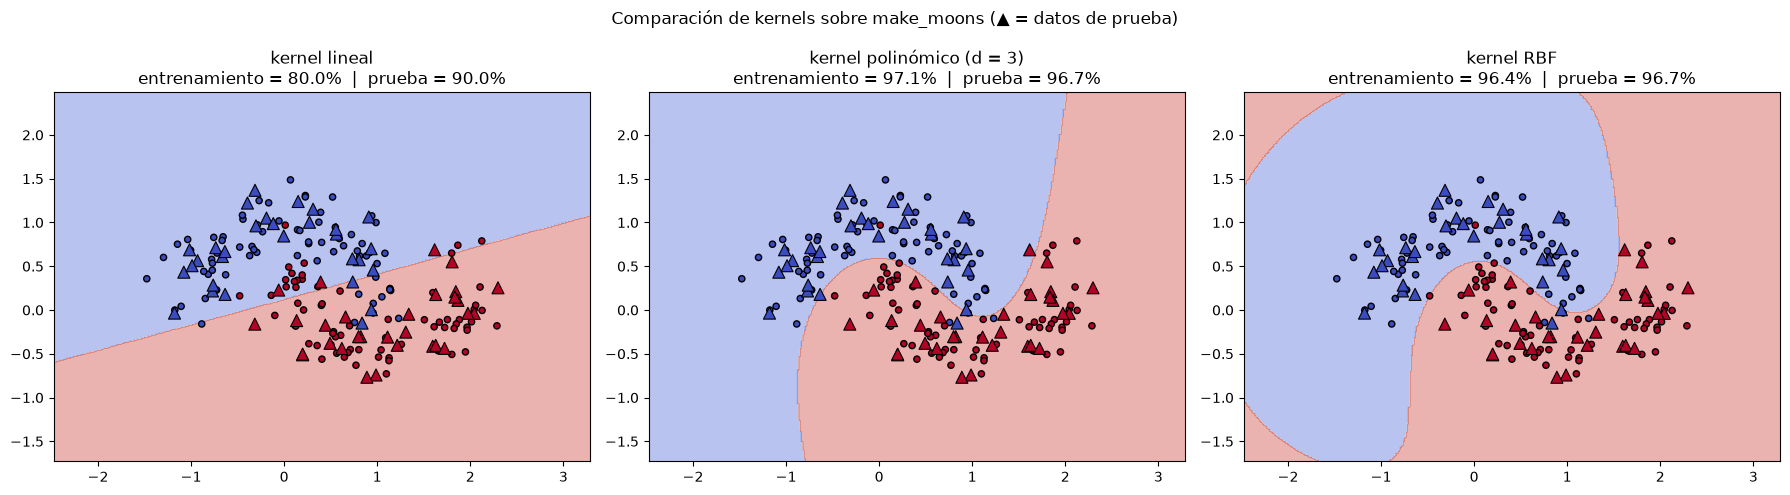

Kernel                               Entrenamiento      Prueba
--------------------------------------------------------------
kernel lineal                               80.0%       90.0%
kernel polinómico (d = 3)                   97.1%       96.7%
kernel RBF                                  96.4%       96.7%


In [ ]:
# ---------- Ejercicio 4: lineal vs. polinómico (d=3) vs. RBF ----------
from sklearn.model_selection import train_test_split

# Dividimos los datos de la Sección 9 en entrenamiento (70%) y prueba (30%)
# para comparar de forma honesta: frontera aprendida vs. datos nunca vistos.
X_tr, X_te, y_tr, y_te = train_test_split(X_moons, y_moons, test_size=0.3,
                                          random_state=42, stratify=y_moons)

kernels = {
    "kernel lineal":            dict(kernel='linear'),
    "kernel polinómico (d = 3)": dict(kernel='poly', degree=3, coef0=1),
    "kernel RBF":               dict(kernel='rbf'),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
resultados = {}
for ax, (nombre, params) in zip(axes, kernels.items()):
    modelo = SVC(C=1, **params).fit(X_tr, y_tr)
    acc_tr = modelo.score(X_tr, y_tr)
    acc_te = modelo.score(X_te, y_te)
    resultados[nombre] = (acc_tr, acc_te)
    plot_frontera_moons(modelo, X_tr, y_tr, ax,
                        f"{nombre}\nentrenamiento = {acc_tr:.1%}  |  prueba = {acc_te:.1%}")
    # Datos de prueba en forma de triángulo para distinguirlos
    ax.scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap='coolwarm', edgecolors='k',
               s=75, marker='^', linewidths=0.8, zorder=5)

plt.suptitle("Comparación de kernels sobre make_moons (▲ = datos de prueba)")
plt.tight_layout()
plt.show()

print(f"{'Kernel':<32}{'Entrenamiento':>18}{'Prueba':>12}")
print("-" * 62)
for nombre, (acc_tr, acc_te) in resultados.items():
    print(f"{nombre:<32}{acc_tr:>17.1%}{acc_te:>12.1%}")


**Respuesta (Ejercicio 4).** Resultados (con `make_moons`, ruido 0.2, 200 puntos, división 70/30 estratificada):

| Kernel | Exactitud (entrenamiento) | Exactitud (prueba) |
|---|---|---|
| Lineal | 80.0% | 90.0% |
| Polinómico (grado 3) | 97.1% | 96.7% |
| **RBF** | **96.4%** | **96.7%** |

- **El kernel lineal es el más inadecuado:** `make_moons` son dos "lunas" entrelazadas y **ninguna recta** puede separarlas; la frontera lineal corta ambas nubes y se queda en 80% (entrenamiento) / 90% (prueba). Es un caso claro de **subajuste**: el modelo es demasiado simple para la forma de los datos.
- **Los kernels no lineales sí resuelven el problema** (~96–97%): tanto el polinómico de grado 3 como el RBF logran fronteras curvas que siguen la forma de las lunas.
- **¿Cuál es el más adecuado?** En exactitud de prueba empatan (96.7%), pero **el RBF es la mejor opción práctica**: no tuvimos que adivinar un grado $d$, es flexible y es la opción por defecto recomendada cuando no conocemos la forma de la frontera. El polinómico de grado 3 sería la elección si tuviéramos una razón para suponer interacciones cúbicas entre las variables (y, si lo usamos, hay que ajustar `degree`, `gamma` y `coef0` con validación cruzada).


---
#### Ejercicio 5 — SVR y el ancho del tubo


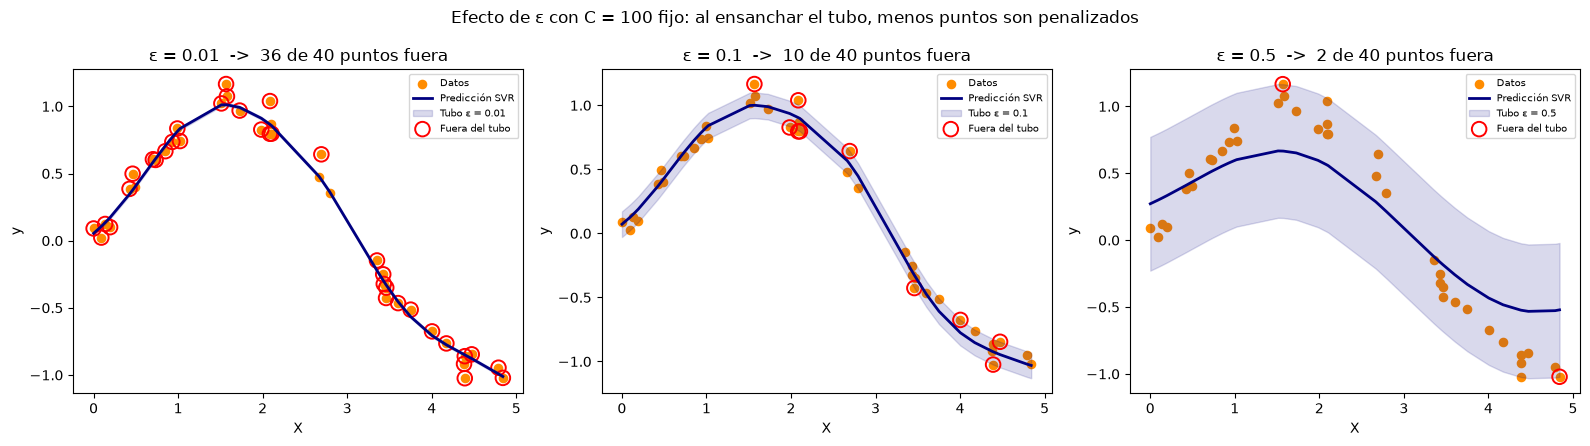

epsilon       Fuera del tubo     Vectores de soporte   MAE (error medio)
------------------------------------------------------------------------
0.01                      36                      38              0.0535
0.1                       10                      13              0.0641
0.5                        2                       3              0.2417


In [ ]:
# ---------- Ejercicio 5a: variando epsilon con C = 100 fijo ----------
epsilons = [0.01, 0.1, 0.5]
C_fijo = 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
tabla_eps = []

for ax, eps in zip(axes, epsilons):
    modelo = SVR(kernel='rbf', C=C_fijo, epsilon=eps).fit(X_reg, y_reg)
    pred = modelo.predict(X_reg)
    fuera = np.abs(y_reg - pred) > eps
    tabla_eps.append((eps, int(fuera.sum()), len(modelo.support_),
                      float(np.abs(y_reg - pred).mean())))

    ax.scatter(X_reg, y_reg, color='darkorange', s=35, label='Datos')
    ax.plot(X_reg, pred, color='navy', lw=2, label='Predicción SVR')
    ax.fill_between(X_reg.ravel(), pred - eps, pred + eps,
                    color='navy', alpha=0.15, label=f'Tubo ε = {eps}')
    ax.scatter(X_reg[fuera], y_reg[fuera], facecolors='none', edgecolors='red',
               s=110, linewidths=1.4, label='Fuera del tubo')
    ax.set_title(f"ε = {eps}  ->  {fuera.sum()} de {len(X_reg)} puntos fuera")
    ax.set_xlabel("X"); ax.set_ylabel("y")
    ax.legend(loc='upper right', fontsize=7)

plt.suptitle("Efecto de ε con C = 100 fijo: al ensanchar el tubo, menos puntos son penalizados")
plt.tight_layout()
plt.show()

print(f"{'epsilon':<10}{'Fuera del tubo':>18}{'Vectores de soporte':>24}{'MAE (error medio)':>20}")
print("-" * 72)
for eps, n_fuera, n_sv_svr, mae in tabla_eps:
    print(f"{eps:<10}{n_fuera:>18}{n_sv_svr:>24}{mae:>20.4f}")


C             Fuera del tubo     Vectores de soporte   MAE (error medio)
------------------------------------------------------------------------
0.1                       21                      24              0.1428
1                          8                      10              0.0614
10                         9                      11              0.0636
100                       10                      13              0.0641
1000                       9                      14              0.0626


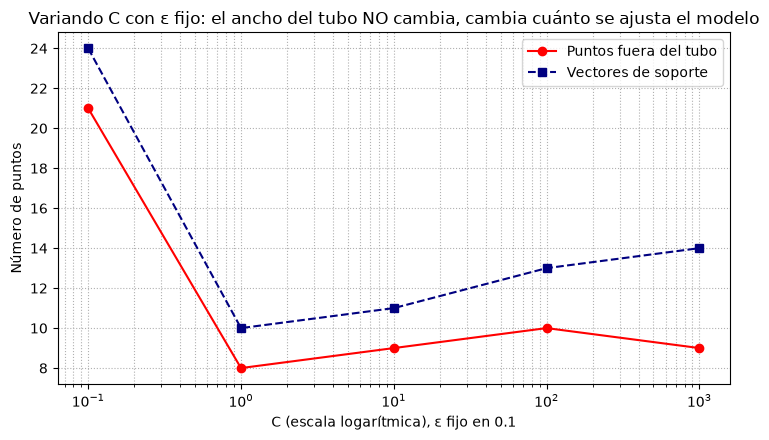

In [ ]:
# ---------- Ejercicio 5b: variando C con epsilon = 0.1 fijo ----------
eps_fijo = 0.1
valores_C = [0.1, 1, 10, 100, 1000]

tabla_C = []
print(f"{'C':<10}{'Fuera del tubo':>18}{'Vectores de soporte':>24}{'MAE (error medio)':>20}")
print("-" * 72)
for C_val in valores_C:
    modelo = SVR(kernel='rbf', C=C_val, epsilon=eps_fijo).fit(X_reg, y_reg)
    pred = modelo.predict(X_reg)
    fuera = np.abs(y_reg - pred) > eps_fijo
    tabla_C.append((C_val, int(fuera.sum()), len(modelo.support_),
                    float(np.abs(y_reg - pred).mean())))
    print(f"{C_val:<10}{int(fuera.sum()):>18}{len(modelo.support_):>24}"
          f"{float(np.abs(y_reg - pred).mean()):>20.4f}")

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
ax1.plot([t[0] for t in tabla_C], [t[1] for t in tabla_C], 'o-', color='red',
         label='Puntos fuera del tubo')
ax1.plot([t[0] for t in tabla_C], [t[2] for t in tabla_C], 's--', color='navy',
         label='Vectores de soporte')
ax1.set_xscale('log')
ax1.set_xlabel(f'C (escala logarítmica), ε fijo en {eps_fijo}')
ax1.set_ylabel('Número de puntos')
ax1.set_title('Variando C con ε fijo: el ancho del tubo NO cambia, cambia cuánto se ajusta el modelo')
ax1.grid(True, which='both', ls=':')
ax1.legend()
plt.tight_layout()
plt.show()


**Respuesta (Ejercicio 5).**

**(a) Variando `epsilon` con `C = 100` fijo:**

| `epsilon` | Puntos fuera del tubo | Vectores de soporte | MAE |
|---|---|---|---|
| 0.01 | 36 / 40 | 38 | 0.0535 |
| 0.10 | 10 / 40 | 13 | 0.0641 |
| 0.50 | 2 / 40 | 3 | 0.2417 |

Al **crecer `epsilon` el tubo se ensancha**, así que cada vez menos puntos quedan fuera de él (36 → 10 → 2) y, consecutivamente, **disminuyen los vectores de soporte** (38 → 13 → 3): menos puntos "importan" para definir la función. La contrapartida es que el modelo deja de penalizar errores pequeños y grandes, así que el error medio (MAE) se dispara (0.05 → 0.24): **tubo ancho = función más suave y sencilla, pero menos ajustada**; **tubo angosto = función más detallada, pero sensible al ruido**.

**(b) Variando `C` con `epsilon = 0.1` fijo:**

| `C` | Puntos fuera del tubo | Vectores de soporte | MAE |
|---|---|---|---|
| 0.1 | 21 | 24 | 0.1428 |
| 1 | 8 | 10 | 0.0614 |
| 10 | 9 | 11 | 0.0636 |
| 100 | 10 | 13 | 0.0641 |
| 1000 | 9 | 14 | 0.0626 |

La diferencia conceptual es importante: **`epsilon` decide el ancho del tubo, mientras que `C` decide cuánto cuesta cada punto que queda fuera**. Con `epsilon` fijo el ancho de la banda es el mismo en todos los casos; lo que cambia es el compromiso del objetivo $\tfrac12\|w\|^2 + C\sum \xi_i$:

- **`C` pequeño (0.1):** al modelo le conviene una función suave ($\|w\|$ pequeño) aunque se equivoque → **21 puntos** quedan fuera del mismo tubo y el error medio sube (0.1428) → posible **subajuste**.
- **`C` grande (≥ 1):** el modelo se dobla para llevar los puntos dentro del tubo → solo 8–10 quedan fuera, el error cae a ~0.06 y **aumentan los vectores de soporte** (más puntos quedan "en contacto" con la función). A partir de `C = 10` los cambios son marginales; empujar `C` demasiado lejos solo arriesga **sobreajuste** (más SV = más dependencia del ruido).

En resumen: para "relajar" el modelo primero se ajusta `epsilon` (qué tan fino exigimos ser) y después `C` (qué tan caro es fallar), siempre con validación cruzada.


---
#### Ejercicio 6 — Pregunta conceptual (sin código)

**Respuesta (Ejercicio 6).** El truco del kernel sería completamente inútil porque **todo el truco consiste en sustituir un único tipo de operación**: la formulación dual de SVM solo necesita, de los datos, los valores de los productos punto $x_i \cdot x_j$ (o $\phi(x_i)\cdot\phi(x_j)$) para $w = \sum_i \alpha_i y_i x_i$ y $f(x) = \sum_i \alpha_i y_i (x_i \cdot x) + b$; nunca las coordenadas por separado. Precisamente por eso podemos reemplazar $\phi(x_i)\cdot\phi(x_j)$ por $K(x_i,x_j)$, que se calcula directamente sobre los datos originales **sin nunca construir $\phi$** — y esa es la única razón por la que podemos meternos en espacios de dimensión infinita (RBF) o de millones de dimensiones sin pagar su costo. Si la función de decisión dependiera de las coordenadas individuales de $x_i$ (por ejemplo, términos sueltos como $x_{i1}$, o productos cruzados concretos entre componentes de $x_i$), necesitaríamos **el vector $\phi(x_i)$ completo**, no un simple número; el kernel solo devuelve el escalar $\phi(x_i)\cdot\phi(x_j)$, de modo que no habría forma de reconstruir las coordenadas de $\phi(x_i)$ a partir de él. Habría que calcular $\phi$ explícitamente en cada punto y evaluar la fórmula componente a componente — en el caso RBF, en un espacio de dimensión infinita, es decir, imposible de computar. El "atajo" solo existe porque la dependencia con los datos es *enteramente* a través de productos punto.

---

#### ✅ Cierre de la sección

Con los seis ejercicios quedan cubiertas las piezas centrales del notebook:

1. Los vectores de soporte son los **únicos** puntos que determinan el hiperplano (mover un punto dentro del margen cambia la solución).
2. `C` gobierna el compromiso margen ancho ↔ violaciones toleradas, y se refleja directamente en la cantidad de vectores de soporte.
3. El kernel polinómico puede verificarse a mano contra su transformación explícita $\phi$ (¡y da $-27$, un valor negativo válido!).
4. Sobre datos no lineales, los kernels `poly` y `rbf` superan claramente al lineal; RBF es la opción por defecto más robusta.
5. En SVR, `epsilon` fija el ancho del tubo y `C` el costo de salirse de él.
6. El truco del kernel solo funciona porque SVM depende de los datos **únicamente** a través de productos punto.


---
## Referencias y para profundizar

- Cortes, C., & Vapnik, V. (1995). *Support-vector networks*. Machine Learning.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Cap. 7.
- Documentación de scikit-learn: [`sklearn.svm`](https://scikit-learn.org/stable/modules/svm.html)
